In [4]:
import numpy as np
 # Dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Activation function and their derivatives
def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
  return x*(1-x)

def tanh_derivative(x):
  return 1-x**2

# MLP class
class MLP_XOR:
  def __init__(self, input_size, hidden_size, output_size, lr=0.5):
    self.lr = lr
    # He initialization for bettter convergence
    self.W1 = np.random.randn(input_size, hidden_size)*0.5
    self.b1= np.zeros((1,hidden_size))
    self.W2 = np.random.randn(hidden_size,output_size)*0.5
    self.b2 = np.zeros((1,output_size))

  def forward(self,X):
    self.z1=np.dot(X,self.W1)+self.b1
    self.a1 =np.tanh(self.z1)     #hidden layer output
    self.z2=np.dot(self.a1,self.W2)+self.b2 # Fixed: added self.a1 as input to dot product
    self.a2 = sigmoid(self.z2)    # output layer(probability)
    return self.a2

  def backward(self,X,y,output):
    m = X.shape[0] # Fixed: changed shap to shape
    #output layer error
    d_loss= output-y     #derivative of BCE with sigmoid
    d_z2 = d_loss*sigmoid_derivative(output) # not strictly needed if using cross-entropy+sigmoid, but kept for clarity
    d_a1 =np.dot(d_loss,self.W2.T) # Fixed: changed W2,T to W2.T
    d_z1 = d_a1*tanh_derivative(self.a1)

    # update weights and biases
    self.W2 -= self.lr*np.dot(self.a1.T,d_loss)/m # Fixed: changed Ir to lr
    self.b2 -=self.lr*np.sum(d_loss,axis =0,keepdims=True)/m # Fixed: changed Ir to lr
    self.W1 -= self.lr*np.dot(X.T,d_z1)/m # Fixed: changed Ir to lr
    self.b1 -= self.lr*np.sum(d_z1,axis=0,keepdims=True)/m # Fixed: changed Ir to lr

  def train(self,X,y,epochs):
    for epoch in range(epochs):
      output = self.forward(X)
      self.backward(X,y,output)
      if epoch % 2000 == 0:
        loss = -np.mean(y * np.log(output + 1e-8) + (1-y) * np.log(1-output + 1e-8))
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
  def predict(self, X):
      return (self.forward(X) >= 0.5).astype(int)

# 4. Train and test
model = MLP_XOR(input_size=2, hidden_size=2, output_size=1, lr=0.7)
model.train(X, y, epochs=10000)

print("\nPredictions after training:")
for i, inp in enumerate(X):
  pred = model.predict(inp.reshape(1, -1))
  print(f"Input: {inp}, Predicted: {pred[0][0]}, Expected: {y[i][0]}")

Epoch 0, Loss: 0.695660
Epoch 2000, Loss: 0.002413
Epoch 4000, Loss: 0.001145
Epoch 6000, Loss: 0.000749
Epoch 8000, Loss: 0.000557

Predictions after training:
Input: [0 0], Predicted: 0, Expected: 0
Input: [0 1], Predicted: 1, Expected: 1
Input: [1 0], Predicted: 1, Expected: 1
Input: [1 1], Predicted: 0, Expected: 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step - accuracy: 0.7500 - loss: 0.7348
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7500 - loss: 0.7010
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6928
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2500 - loss: 0.6954
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.6946
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2500 - loss: 0.6883
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.6793
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6700
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6609
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6514
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7500 - loss: 0.6408
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy

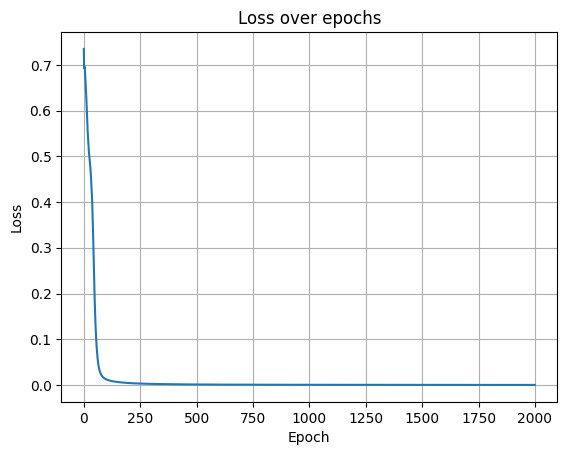

In [7]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 2. Build the model using Sequential API
model = keras.Sequential([
keras.layers.Dense(2, activation='tanh', input_shape=(2,), name='hidden_layer'),
keras.layers.Dense(1, activation='sigmoid', name='output_layer')
])
# 3. Compile the model
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=0.1),
loss='binary_crossentropy',
metrics=['accuracy']
)
# 4. Display model summary
model.summary()
# 5. Train the model
history = model.fit(
X, y,
epochs=2000,
verbose=1, # set to 0 to suppress output
batch_size=4
)
# 6. Evaluate and predict
print("\nFinal Predictions:")

predictions = model.predict(X)
for i, inp in enumerate(X):
  pred_class = 1 if predictions[i] >= 0.5 else 0
  print(f"Input: {inp}, Probability: {predictions[i][0]:.4f}, Class: {pred_class}, Expected:\n{y[i][0]}")
# 7. (Optional) Visualize training loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()